In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

# **Load Dataset:**

In [2]:
df=pd.read_csv('/content/heart.csv')
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


# **Data Cleaning:**

In [5]:
df.isnull().sum()
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


# **EDA(Exploratory Data Analysis):**

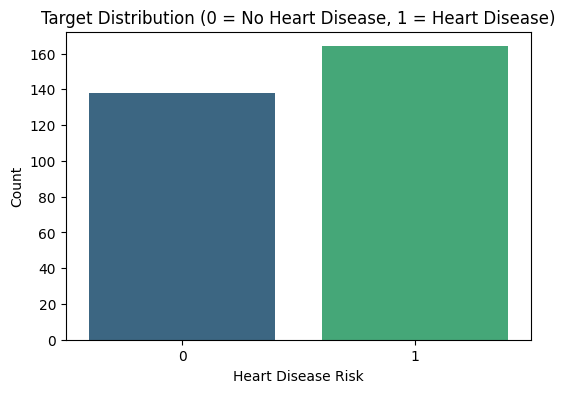

In [6]:
# Target distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette='viridis')
plt.title('Target Distribution (0 = No Heart Disease, 1 = Heart Disease)')
plt.xlabel('Heart Disease Risk')
plt.ylabel('Count')
plt.show()

In [11]:
# checking the distribution of Target Variable
print("Target Value Counts (%):")
df['target'].value_counts(normalize=True) * 100

Target Value Counts (%):


,proportion
target,
1,54.304636
0,45.695364


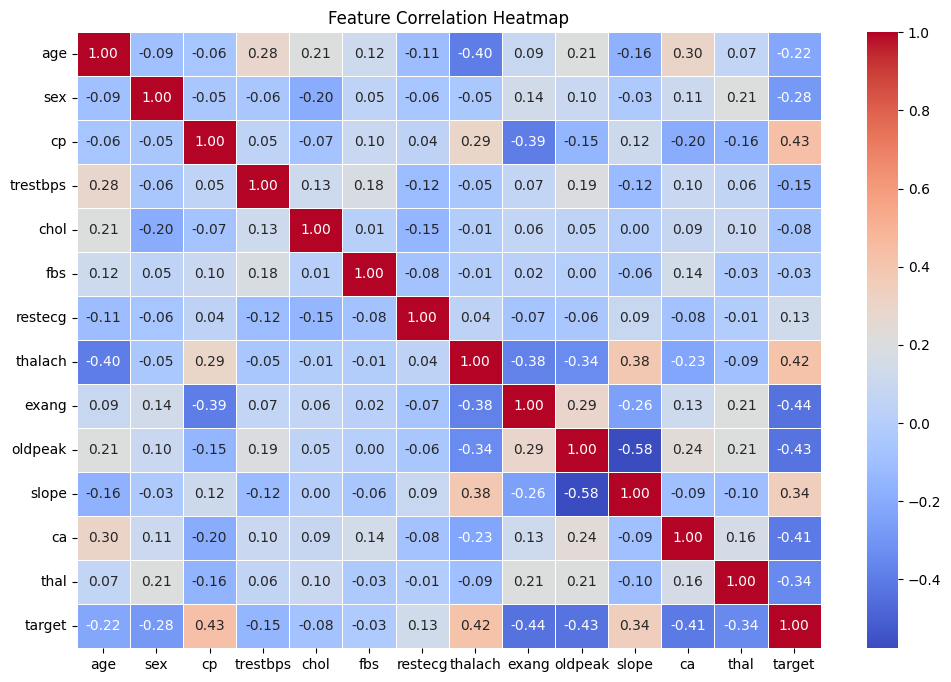

In [12]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

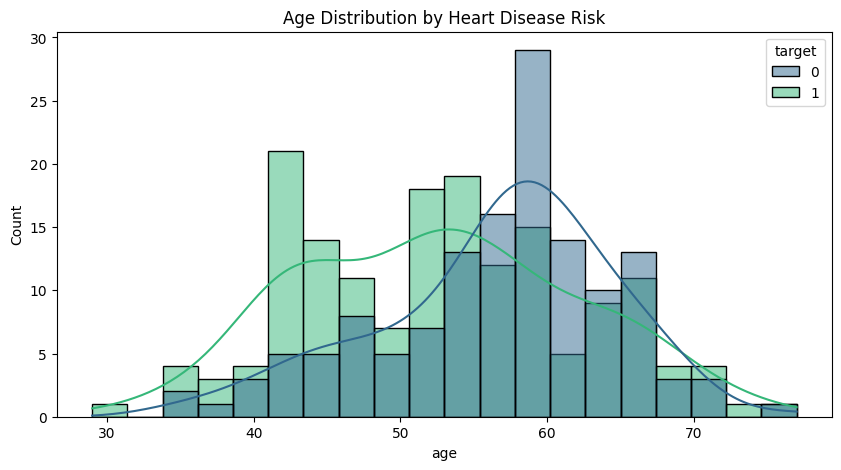

In [13]:
# Key visualizations
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='age', hue='target', kde=True, bins=20, palette='viridis')
plt.title('Age Distribution by Heart Disease Risk')
plt.show()

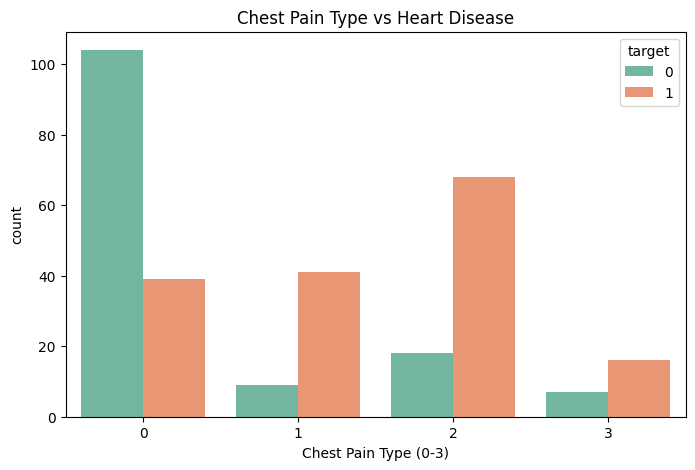

In [14]:
plt.figure(figsize=(8, 5))
sns.countplot(x='cp', hue='target', data=df, palette='Set2')
plt.title('Chest Pain Type vs Heart Disease')
plt.xlabel('Chest Pain Type (0-3)')
plt.show()

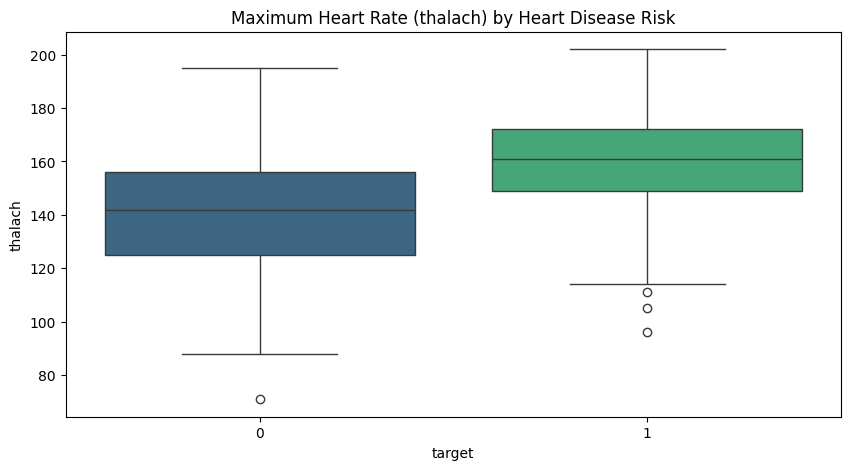

In [15]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='target', y='thalach', data=df, palette='viridis')
plt.title('Maximum Heart Rate (thalach) by Heart Disease Risk')
plt.show()

# **Prepare Data for Modeling:**

In [20]:
X = df.drop('target', axis=1)
y = df['target']
# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")


Training samples: 241
Testing samples: 61


# ***Train Logistic Regression Model:***

In [21]:
model = LogisticRegression()
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
# Predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# **Model Evaluation:**

In [22]:
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Heart Disease']))

✅ Accuracy: 0.8197 (81.97%)

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.80      0.83      0.81        29
Heart Disease       0.84      0.81      0.83        32

     accuracy                           0.82        61
    macro avg       0.82      0.82      0.82        61
 weighted avg       0.82      0.82      0.82        61



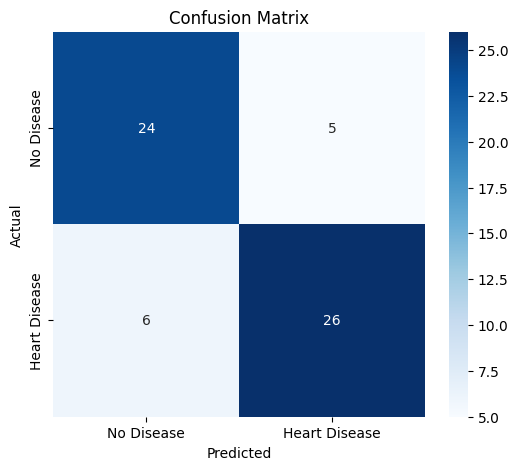

In [23]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Heart Disease'],
            yticklabels=['No Disease', 'Heart Disease'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

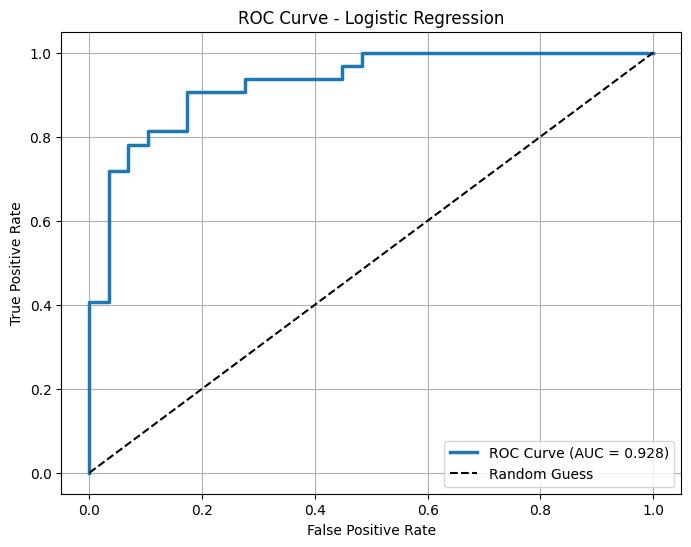

📈 ROC AUC Score: 0.9278


In [25]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})', linewidth=2.5)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.grid(True)
plt.show()
print(f"📈 ROC AUC Score: {roc_auc:.4f}")

# **Feature Importance:**

In [26]:
print("\n=== Most Important Features ===")
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0],
    'Abs_Impact': abs(model.coef_[0])
}).sort_values(by='Abs_Impact', ascending=False)

print(coefficients.round(4))

print("\n✅ Top 5 features with highest impact:")
print(coefficients.head(5)[['Feature', 'Coefficient']])


=== Most Important Features ===
     Feature  Coefficient  Abs_Impact
1        sex      -1.4268      1.4268
12      thal      -1.0213      1.0213
8      exang      -0.8976      0.8976
11        ca      -0.7900      0.7900
10     slope       0.7131      0.7131
2         cp       0.6509      0.6509
9    oldpeak      -0.4895      0.4895
6    restecg       0.4660      0.4660
5        fbs       0.3168      0.3168
3   trestbps      -0.0255      0.0255
7    thalach       0.0250      0.0250
0        age       0.0043      0.0043
4       chol      -0.0035      0.0035

✅ Top 5 features with highest impact:
   Feature  Coefficient
1      sex    -1.426758
12    thal    -1.021302
8    exang    -0.897613
11      ca    -0.789977
10   slope     0.713108
